In [3]:
import pandas as pd

df = pd.read_csv("D:\\CodeAlpha_Intern_Tasks\\Credit_Scoring_Project\\credit_risk_dataset.csv")

print(df.head(5))
print(df.shape)

# import pandas as pd
# Imports the Pandas library and assigns it the alias 'pd'.
# Pandas is used for data manipulation, analysis, and handling tabular datasets.

# df = pd.read_csv("credit_data.csv")
# Loads the credit scoring dataset from a CSV file and stores it in a DataFrame named 'df'.

# print(df.head())
# Displays the first five rows of the dataset to provide an initial overview of the data.

# print(df.shape)
# Returns the dimensions of the dataset, showing the total number of rows and columns.

   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y                           3  


In [4]:
print(df.columns)
#prints the column names present in dataset

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')


In [5]:
print(df.info())

# df.info()
# Displays a summary of the DataFrame including column names,
# data types, non-null values, and memory usage.
# It helps understand the structure of the dataset and identify missing values.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB
None


In [6]:
print(df.isnull().sum())



# df.info()
# Displays a summary of the DataFrame including column names,
# data types, non-null values, and memory usage.
# It helps understand the structure of the dataset and identify missing values.

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


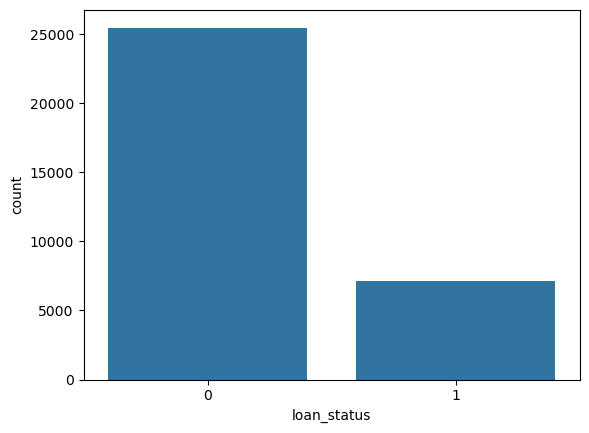

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='loan_status', data=df)
plt.show()

In [8]:
df['person_emp_length'] = df['person_emp_length'].fillna(
    df['person_emp_length'].median()
)
# Fills missing values in the 'person_emp_length' column using the median value.
# The median is used because it is less affected by outliers and provides
# a reliable estimate for missing employment length records.

df['loan_int_rate'] = df['loan_int_rate'].fillna(
    df['loan_int_rate'].median()
)
# Replaces missing values in the 'loan_int_rate' column with the median interest rate.
# This ensures that the dataset contains no null values in this feature
# and prevents issues during model training.

In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['person_home_ownership'] = le.fit_transform(df['person_home_ownership'])

# Imports the LabelEncoder class from Scikit-learn.
# LabelEncoder is used to convert categorical text values into numerical labels
# that can be processed by machine learning algorithms.
# Creates an instance of the LabelEncoder class.
# This object will be used to transform categorical features into numerical format.
# Converts the categorical values in 'person_home_ownership'
# (e.g., RENT, OWN, MORTGAGE) into numerical labels.
# This makes the feature suitable for machine learning models.

In [10]:
df['cb_person_default_on_file'] = df['cb_person_default_on_file'].map({
    'Y': 1,
    'N': 0
})

# Converts the values in 'cb_person_default_on_file' into numerical format.
# 'Y' (Yes) is mapped to 1 and 'N' (No) is mapped to 0.
# This creates a binary feature that can be used by machine learning algorithms.

In [11]:
df = pd.get_dummies(
    df,
    columns=['loan_intent', 'loan_grade'],
    drop_first=True
)


# Applies One-Hot Encoding to the 'loan_intent' and 'loan_grade' columns.
# Creates separate binary columns for each category while removing the first category
# to avoid multicollinearity (dummy variable trap).
# This converts categorical data into a numerical format suitable for model training.

In [12]:
print(df.head())

   person_age  person_income  person_home_ownership  person_emp_length  \
0          22          59000                      3              123.0   
1          21           9600                      2                5.0   
2          25           9600                      0                1.0   
3          23          65500                      3                4.0   
4          24          54400                      3                8.0   

   loan_amnt  loan_int_rate  loan_status  loan_percent_income  \
0      35000          16.02            1                 0.59   
1       1000          11.14            0                 0.10   
2       5500          12.87            1                 0.57   
3      35000          15.23            1                 0.53   
4      35000          14.27            1                 0.55   

   cb_person_default_on_file  cb_person_cred_hist_length  ...  \
0                          1                           3  ...   
1                          0      

In [13]:
X = df.drop('loan_status', axis=1)

y = df['loan_status']

# X = df.drop("loan_status", axis=1)
# Removes the "loan_status" column from the dataset and stores the remaining columns in X.
# X represents the input features (independent variables) used for model training.

# y = df["loan_status"]
# Extracts the "loan_status" column and stores it in y.
# y represents the target variable (dependent variable) that we want to predict.

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

# from sklearn.model_selection import train_test_split
# Imports the train_test_split function from Scikit-learn, used to split dataset into training and testing sets.

# X_train, X_test, y_train, y_test = train_test_split(...)
# Splits the dataset into training and testing parts:
# X_train → input features for training the model
# X_test → input features for testing the model
# y_train → target values for training
# y_test → target values for testing

# test_size=0.2
# 20% of the data is used for testing, while 80% is used for training the model.

# random_state=42
# Ensures reproducibility of the split so that the same results are obtained every time the code is run.

In [15]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)


#from sklearn.linear_model import LogisticRegression
# Imports Logistic Regression model from scikit-learn library.
# This model is used for classification problems (e.g., Yes/No, 0/1 predictions).

#lr_model = LogisticRegression(max_iter=1000)
# Creates an instance of Logistic Regression model.
# max_iter=1000 sets the maximum number of iterations for the solver to converge properly.

#lr_model.fit(X_train, y_train)
# Trains the model using training data.
# X_train contains input features (independent variables),
# y_train contains target labels (dependent variable).
# The model learns patterns between inputs and outputs.

#lr_pred = lr_model.predict(X_test)
# Uses the trained model to make predictions on unseen test data.
# X_test is input data, and lr_pred stores predicted outputs (0/1 or class labels).

C:\Users\rizwa\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [16]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)


#from sklearn.tree import DecisionTreeClassifier
# Imports Decision Tree Classifier from scikit-learn library.
# This model is used for classification problems by splitting data into branches based on feature conditions.

#dt_model = DecisionTreeClassifier(random_state=42)
# Creates an instance of Decision Tree model.
# random_state=42 ensures reproducibility (same results every time code runs).

#dt_model.fit(X_train, y_train)
# Trains the decision tree model using training data.
# X_train contains input features (independent variables),
# y_train contains target labels (dependent variable).
# The model learns decision rules by splitting data at different feature values.

# dt_pred = dt_model.predict(X_test)
# Uses the trained decision tree model to predict outputs on test data.
# X_test is unseen data, and dt_pred stores predicted class labels (e.g., 0 or 1).

In [17]:

# Import Random Forest model
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
# n_estimators = number of trees
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model on training data
rf_model.fit(X_train, y_train)

# Make predictions on test data
rf_predictions = rf_model.predict(X_test)


In [18]:
from sklearn.metrics import accuracy_score

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
rf_accuracy = accuracy_score(y_test, rf_predictions)
print("Random Forest Accuracy:", round(rf_accuracy * 100, 2), "%")


#from sklearn.metrics import accuracy_score
# Imports accuracy_score function from scikit-learn.
# It is used to measure how many predictions are correctly classified by the model.

#print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
# Calculates and prints accuracy of Logistic Regression model.
# Compares actual values (y_test) with predicted values (lr_pred).
# Shows how well Logistic Regression is performing on test data.

#print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
# Calculates and prints accuracy of Decision Tree model.
# Compares actual values (y_test) with predicted values (dt_pred).
# Helps to evaluate and compare performance of both models.

Logistic Regression Accuracy: 0.831210679760626
Decision Tree Accuracy: 0.8909007211907319
Random Forest Accuracy: 93.34 %


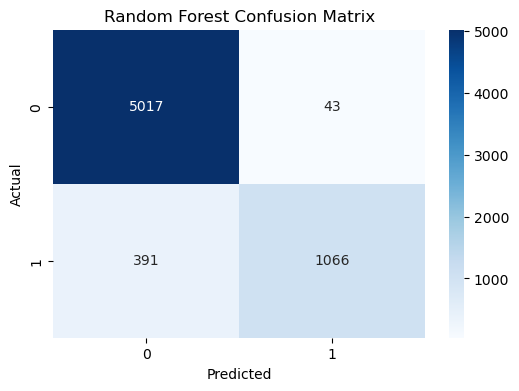

In [19]:
# ==============================
# Confusion Matrix
# ==============================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, rf_predictions)

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# ==============================
# Classification Report
# ==============================

from sklearn.metrics import classification_report

print(classification_report(y_test, rf_predictions))

In [ ]:
import joblib

joblib.dump(rf, "credit_score.pkl")



# import joblib
# Imports the joblib library, used for saving and loading trained machine learning models.

# joblib.dump(model, "diabetes_model.pkl")
# Saves the trained Logistic Regression model into a file named "diabetes_model.pkl".
# This allows the model to be reused later without retraining.

# joblib.dump(scaler, "scaler.pkl")
# Saves the fitted StandardScaler object into a file named "scaler.pkl".
# This ensures that the same scaling can be applied during future predictions.